In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests


In [2]:
# Generating synthetic data to mimic the 2009-2012 Unemployment Rate example
dates = pd.date_range(start='2009-01-01', periods=48, freq='M')
# Create a curve that rises then slowly falls
values = [7.8 + (x * 0.1) if x < 15 else 9.3 - ((x-15) * 0.05) for x in range(48)]
# Add some noise
np.random.seed(42)
values = np.array(values) + np.random.normal(0, 0.05, 48)

df = pd.DataFrame({'Date': dates, 'Unemployment Rate': values})

/var/folders/_w/2nv27l3d45v4z5xzfwrb7bz40000gn/T/ipykernel_4461/3217837757.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start='2009-01-01', periods=48, freq='M')


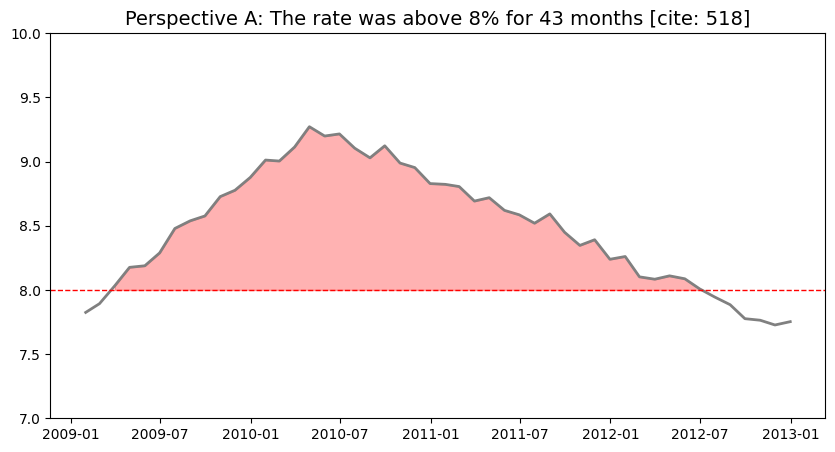

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the line
ax.plot(df['Date'], df['Unemployment Rate'], color='grey', linewidth=2)

# RHETORICAL CHOICE: Fill the area above 8% to emphasize "High Unemployment"
ax.fill_between(df['Date'], df['Unemployment Rate'], 8.0, where=(df['Unemployment Rate'] >= 8.0),
                color='red', alpha=0.3, label='Above 8% Threshold')

# Add threshold line
ax.axhline(y=8.0, color='red', linestyle='--', linewidth=1)

ax.set_title("Perspective A: The rate was above 8% for 43 months [cite: 518]", fontsize=14)
ax.set_ylim(7, 10)
plt.show()

In [4]:
data_types_df = pd.DataFrame({
    'Fruit (Categorical)': ['Apple', 'Orange', 'Pear', 'Apple'],
    'Size (Ordered)': ['Small', 'Large', 'Medium', 'Small'],
    'Price (Quantitative)': [1.50, 2.00, 1.75, 1.45],
    'Count (Quantitative)': [10, 5, 8, 12]
})

display(data_types_df)
# Observe how different columns require different plotting strategies
# (e.g., Bar charts for Categorical, Scatter plots for Quantitative)

,Fruit (Categorical),Size (Ordered),Price (Quantitative),Count (Quantitative)
0,Apple,Small,1.50,10
1,Orange,Large,2.00,5
2,Pear,Medium,1.75,8
3,Apple,Small,1.45,12


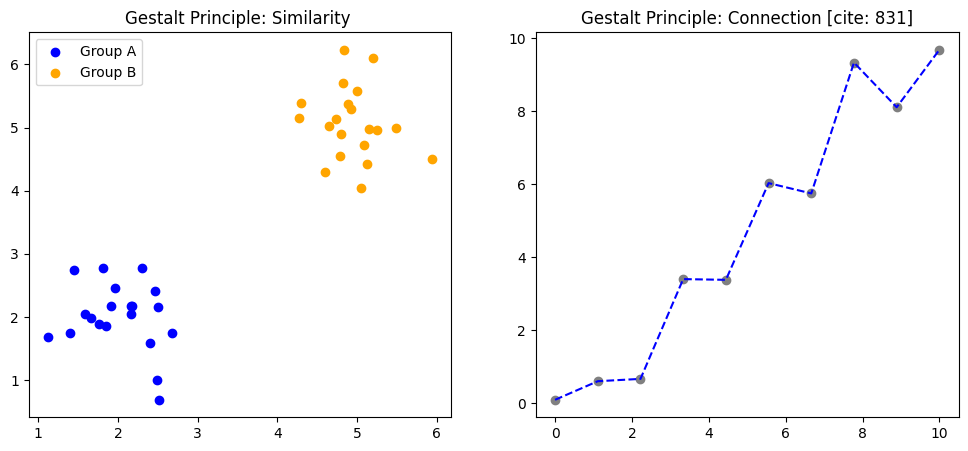

In [5]:
# Generate random clusters
x1 = np.random.normal(2, 0.5, 20)
y1 = np.random.normal(2, 0.5, 20)
x2 = np.random.normal(5, 0.5, 20)
y2 = np.random.normal(5, 0.5, 20)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. Similarity (Grouping by Color)
ax1.scatter(x1, y1, color='blue', label='Group A')
ax1.scatter(x2, y2, color='orange', label='Group B')
ax1.set_title("Gestalt Principle: Similarity ")
ax1.legend()

# 2. Connection (Grouping by Lines)
# Even if points are far apart, a line makes us perceive them as a group [cite: 831]
x_line = np.linspace(0, 10, 10)
y_line = x_line + np.random.normal(0, 1, 10)

ax2.scatter(x_line, y_line, color='grey') # The points
ax2.plot(x_line, y_line, color='blue', linestyle='--') # The connection
ax2.set_title("Gestalt Principle: Connection [cite: 831]")

plt.show()

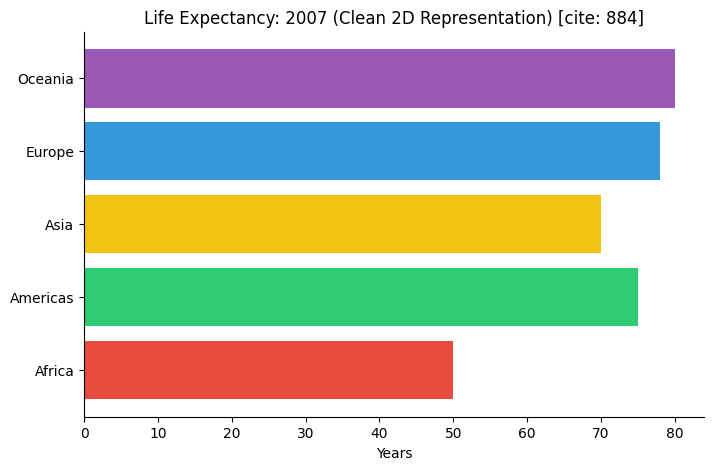

In [6]:
# Data from Slide 39 "Life Expectancy" example
continents = ['Africa', 'Americas', 'Asia', 'Europe', 'Oceania']
life_exp = [50, 75, 70, 78, 80] # Approximate values based on the visual

fig, ax = plt.subplots(figsize=(8, 5))

# A clean 2D bar chart reduces cognitive load compared to the 3D version on Slide 39
ax.barh(continents, life_exp, color=['#e74c3c', '#2ecc71', '#f1c40f', '#3498db', '#9b59b6'])

ax.set_xlabel("Years")
ax.set_title("Life Expectancy: 2007 (Clean 2D Representation) [cite: 884]")

# Remove "chart junk" (spines) to further reduce load
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()